In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
import numpy as np

from imagematerials.rest_of import rest_of_preprocessing
import matplotlib.pyplot as plt


In [2]:
#load historic data
from imagematerials.rest_of.resource_model import ResourceModel

scenario_name = "SSP2_VLLO_LifeTech"
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                        image_mat_available = True, start_year = 1971,
                        scenario=scenario_name,
                        convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                        trade_data=True, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image"))

aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                        image_mat_available = True, start_year = 1998, 
                        scenario=scenario_name, end_year = 2024, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image")
                        )

cement = ResourceModel(resource_group = 'nmm', resource = 'cement', 
                    image_mat_available = True, start_year = 1971, 
                    scenario=scenario_name,
                    convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                    trade_data=True, path_input_data="../data/raw/rest-of", 
                    path_input_data_image = Path("../data/raw/image"))

copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 1990,
                       scenario= scenario_name, end_year = 2011,
                       path_input_data="../data/raw/rest-of", 
                       path_input_data_image = Path("../data/raw/image"))

sand = ResourceModel(resource_group = 'nmm', resource = 'sand_gravel_crushed_rock', 
                       image_mat_available = True, start_year = 1970, scenario= scenario_name, 
                       path_input_data="../data/raw/rest-of", 
                    path_input_data_image = Path("../data/raw/image"))

limestone = ResourceModel(resource_group = 'nmm', resource = 'limestone', 
                    image_mat_available = False, start_year = 1970, scenario=scenario_name, 
                    path_input_data="../data/raw/rest-of", 
                    path_input_data_image = Path("../data/raw/image"))

clay = ResourceModel(resource_group = 'nmm', resource = 'clays', 
                    image_mat_available = False, start_year = 1970, 
                    scenario=scenario_name, 
                    path_input_data="../data/raw/rest-of", 
                    path_input_data_image = Path("../data/raw/image"))



In [3]:
climate_policy_scenario_dir = Path("..", "data", "raw", "image", scenario_name)

In [4]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
rest_sector = rest_of_preprocessing(Path("..", "data", "raw"), 
                    image_scenario_directory = climate_policy_scenario_dir)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

vhc_sector = Sector('vehicles', prep_data)
rest_sector = Sector(name='rest_of', 
                    data = rest_sector,)

factory = ModelFactory(
[bld_sector, vhc_sector, rest_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
).add(MaterialIntensities, "buildings",
).add(RestOf, "rest_of", input_sources={
    "gompertz_coefs": "rest_of",
    "gdp_per_capita": "rest_of",
    "population": "rest_of",
    "historic_diff_consumption": "rest_of"
}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)



c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1689: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [5]:
# sum inflow materials for steel, sum also per types keep regions and year

materials_dict_metal = {
    'Steel' : 'Steel',
    'Aluminium' : 'Aluminium',
    'Copper' : 'Cu',
}

materials_dict_nmm = {
    'Cement' : 'Cement',
    'Sand' : 'Sand'
}

# Conversion factors
# always taking the lower range numbers to be cautios

# https://civiltoday.com/civil-engineering-materials/cement/10-cement-ingredients-with-functions
# Cement: Lime 60-75%, Silica 17-25%, other aggregates
# https://concretesupplyco.com/concrete-basics/
# Concrete:  10% cement, 20% air and water, 30% sand, and 40% gravel --> 30% + 40% = 70%
# https://samsa.org.uk/key_uses/glass.php, https://www.carmeuse.com/na-en/references/case-studies-success-stories/limestone-glassmaking-what-you-need-know
# Sand (silica) in glass: 70%, lime: 15%

from imagematerials.rest_of.preprocessing.sum_sectors_image_materials import sum_inflows_for_output

total_material_dict_metals = sum_inflows_for_output(model, materials_dict_metal, 'metals', save = False)
total_material_dict_nmm = sum_inflows_for_output(model, materials_dict_nmm, 'nmm', save = False)



Steel
Aluminium
Copper
Cement
Sand


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: Uni

In [6]:
def plot_materials_total(material_class, material: str, ax=None):
    # stack plot of material inflow in buildings and vehicles
    material_sel = material
    all_regions = list(range(1, 27))

    if material == "Copper":
        material_sel_veh = "Cu"
    else:
        material_sel_veh = material

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'})
    
    if material in ["Cement"]:
        inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_buildings.loc[material_class.end_year:]

    elif material in ["Sand"]:

        inflow_vehicles_buildings = total_material_dict_nmm["sand_gravel_crushed_rock"].sum(axis = 1)
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_vehicles_buildings.loc[material_class.end_year:]

    else: 
        inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel_veh).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_buildings.loc[material_class.end_year:] + inflow_vehicles.loc[material_class.end_year:]

    years = inflow_buildings.coords['time'].values

    
    historic_consumption_data = material_class.historic_consumption_data.sum(axis = 1) / 1e6
    
    if material in ["Cement"]:
        ax.stackplot(years, inflow_buildings, labels=['Buildings'])

    elif material in ["Sand"]:
        ax.stackplot(years, inflow_vehicles_buildings, labels=['Buildings & Vehicles'])

    else: 
        ax.stackplot(years, inflow_buildings, inflow_vehicles, labels=['Buildings', 'Vehicles'])

    historic_consumption_data.plot(ax=ax, label = "historic consumption")
    inflow_rest_total.plot(ax=ax, label = "Rest of Economy", linestyle='--')

    ax.set_title(f'{material_sel} Global')
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflow (Mt)')
    ax.legend(loc='upper left')
    
    return ax

    

In [7]:
def plot_materials_total(material_class, material: str, ax=None):
    # stack plot of material inflow in buildings and vehicles
    material_sel = material
    all_regions = list(range(1, 27))

    if material == "Copper":
        material_sel_veh = "Cu"
    else:
        material_sel_veh = material

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'})
    
    if material in ["Cement"]:
        inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_buildings.loc[material_class.end_year:]

    elif material in ["Sand"]:

        inflow_vehicles_buildings = total_material_dict_nmm["sand_gravel_crushed_rock"].sum(axis = 1)
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_vehicles_buildings.loc[material_class.end_year:]

    else: 
        inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel_veh).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
        inflow_rest_total = inflow_rest.loc[material_class.end_year:] + inflow_buildings.loc[material_class.end_year:] + inflow_vehicles.loc[material_class.end_year:]

    years = inflow_buildings.coords['time'].values

    
    historic_consumption_data = material_class.historic_consumption_data.sum(axis = 1) / 1e6
    
    if material in ["Cement"]:
        ax.stackplot(years, inflow_buildings, labels=['Buildings'])

    elif material in ["Sand"]:
        ax.stackplot(years, inflow_vehicles_buildings, labels=['Buildings & Vehicles'])

    else: 
        ax.stackplot(years, inflow_buildings, inflow_vehicles, labels=['Buildings', 'Vehicles'])

    historic_consumption_data.plot(ax=ax, label = "historic consumption")
    inflow_rest_total.plot(ax=ax, label = "Rest of Economy", linestyle='--')

    ax.set_title(f'{material_sel} Global')
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflow (Mt)')
    ax.legend(loc='upper left')
    
    return ax

    

In [8]:
def plot_materials_total_no_sectors(material_class, material: str, ax=None):
    # stack plot of material inflow in buildings and vehicles
    material_sel = material

    inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'}).loc[material_class.end_year:]
    
    historic_consumption_data = material_class.historic_consumption_data.sum(axis = 1) / 1e6
    
    inflow_rest.plot(ax=ax, label = "Rest of Economy", linestyle='--')
    historic_consumption_data.plot(ax=ax, label = "historic consumption")

    ax.set_title(f'{material_sel} Global')
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflow (Mt)')
    # ax.legend(loc='upper left')
    
    return ax

    

c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


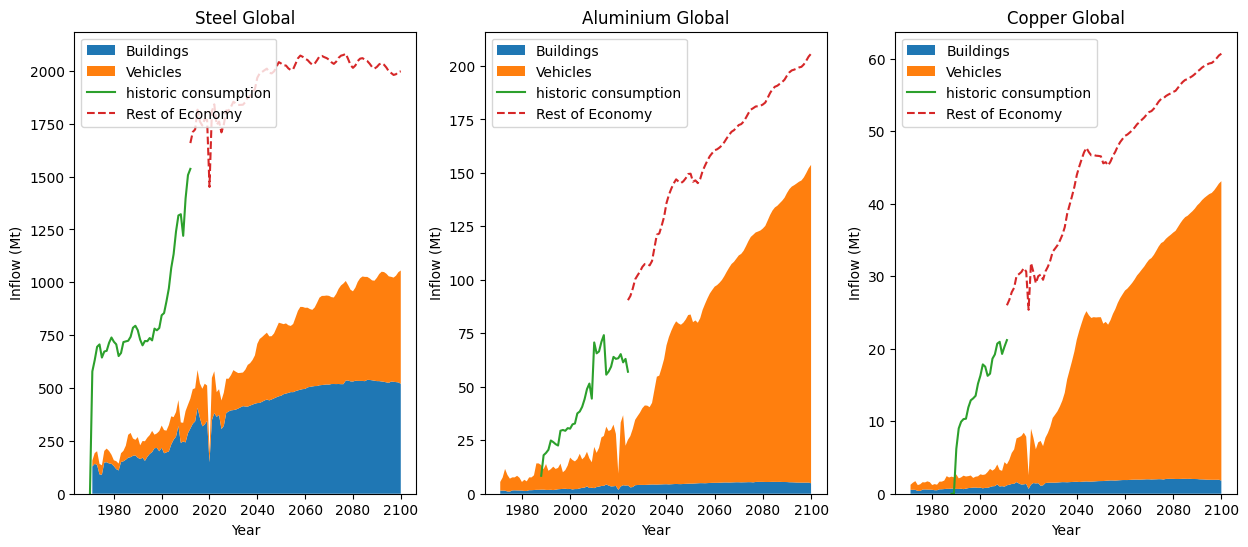

In [18]:
# create plot for all metals and nmm

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes  # First row
# ax4, ax5, ax6 = axes[1]  # Second row

plot_materials_total(steel, "Steel", ax1)
plot_materials_total(aluminium, "Aluminium", ax2)
plot_materials_total(copper, "Copper", ax3)
# plot_materials_total(cement, "Cement", ax4)
# plot_materials_total_no_sectors(sand, "Sand", ax5)
# plot_materials_total_no_sectors(clay, "Limestone", ax6)

plt.legend()


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


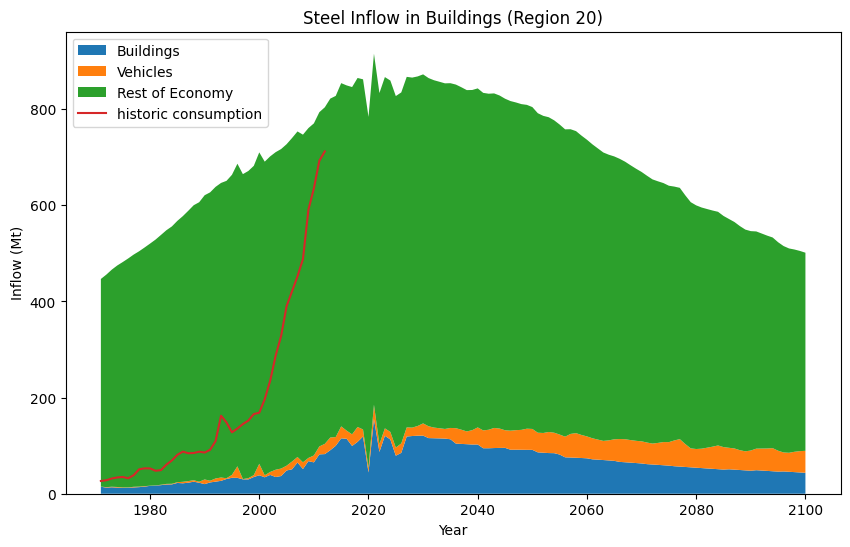

In [10]:
# stack plot of material inflow in buildings and vehicles
from imagematerials.rest_of.const import COPPER_AVERAGE_REGIONS_TO_IMAGE, IAI_TO_IMAGE_CLASSES
COPPER_AVERAGE_REGIONS_TO_IMAGE


material_sel = "Steel"
# all_regions = list(range(1, 27))
region_sel = "20"
import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).sum(["Type"]).loc[1971:].pint.to("Mt")
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).sum(["Type"]).loc[1971:].pint.to("Mt")
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel, Region = region_sel).loc[1971:].rename({'Time': 'time'}).pint.to("Mt")
years = inflow_buildings.coords['time'].values

historic_consumption_data = steel.historic_consumption_data.loc[:, f"class_ {region_sel}"] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Inflow in Buildings (Region {region_sel})')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Grouping: Africa, Regions: ['class_ 7', 'class_ 8', 'class_ 9', 'class_ 10', 'class_ 26']


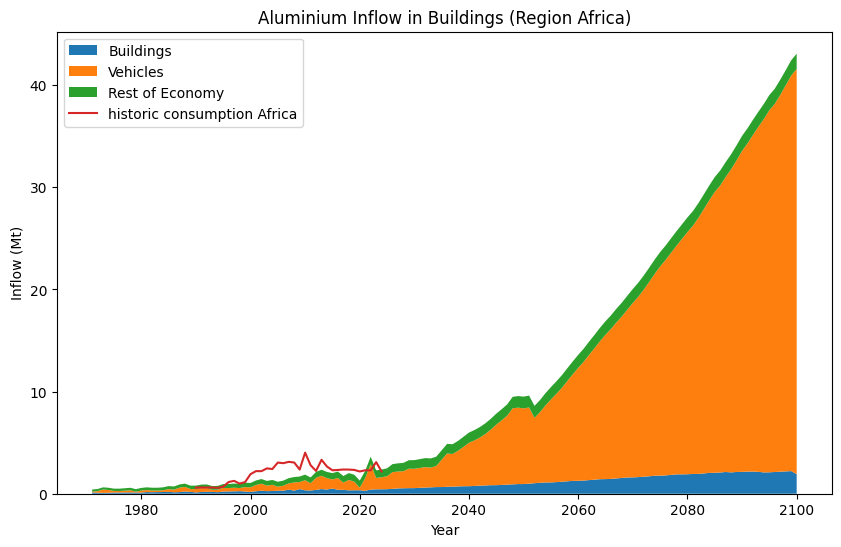

Grouping: Asia (ex China), Regions: ['class_ 17', 'class_ 18', 'class_ 19', 'class_ 21', 'class_ 22', 'class_ 25']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


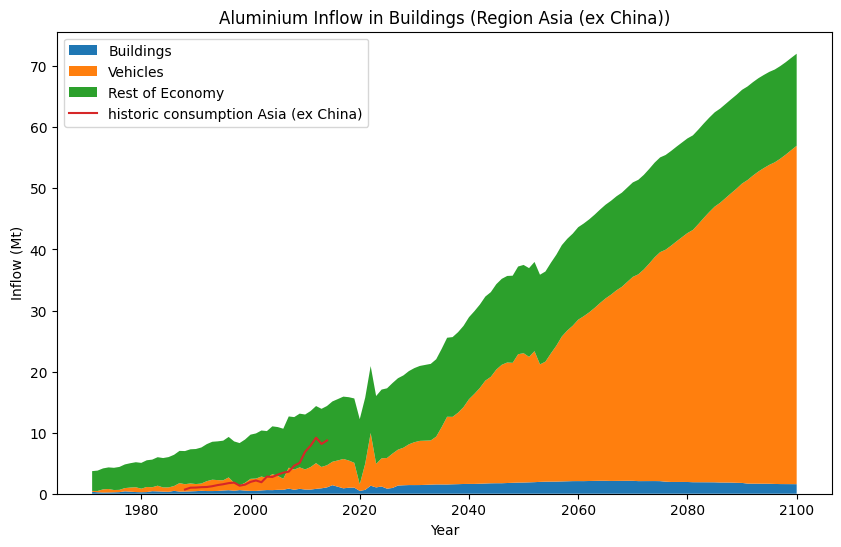

Grouping: Japan, Regions: ['class_ 23']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


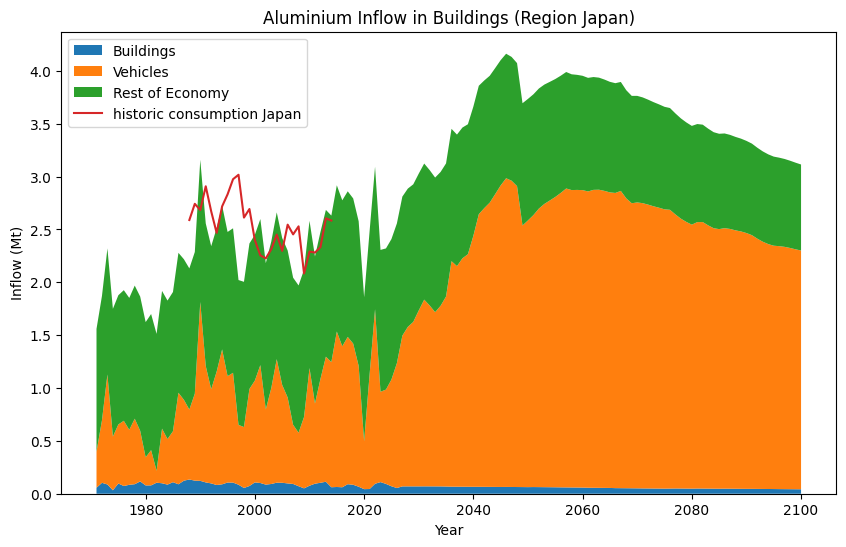

Grouping: China (Estimated), Regions: ['class_ 20']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


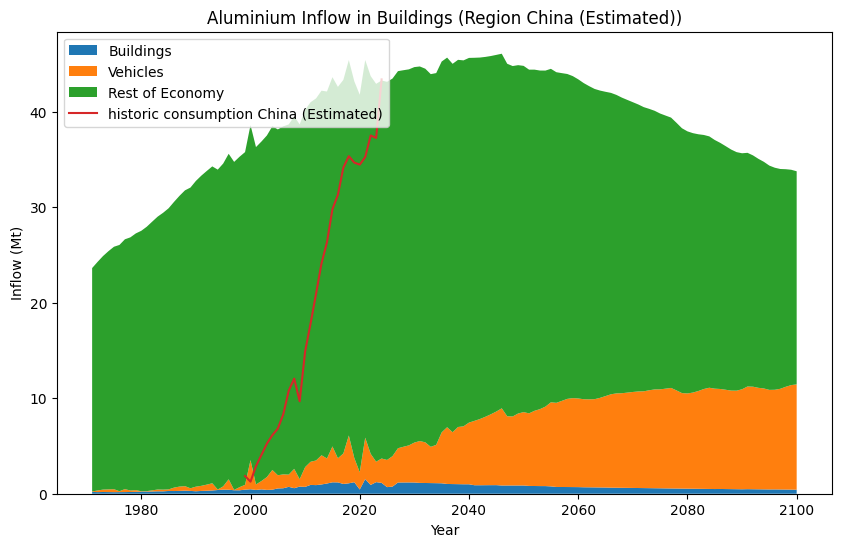

Grouping: Estimated Unreported to IAI, Regions: ['class_ 6', 'class_ 8', 'class_ 10', 'class_ 26']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


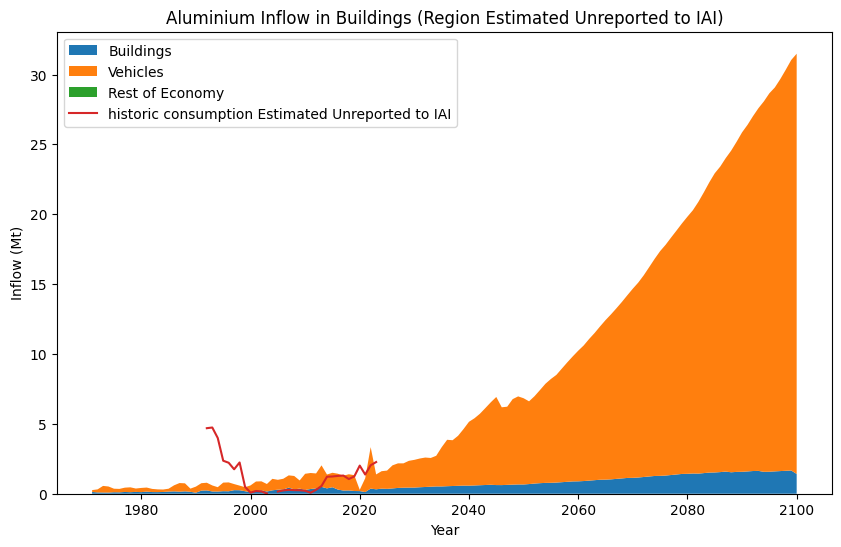

Grouping: Gulf Cooperation Council, Regions: ['class_ 17']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


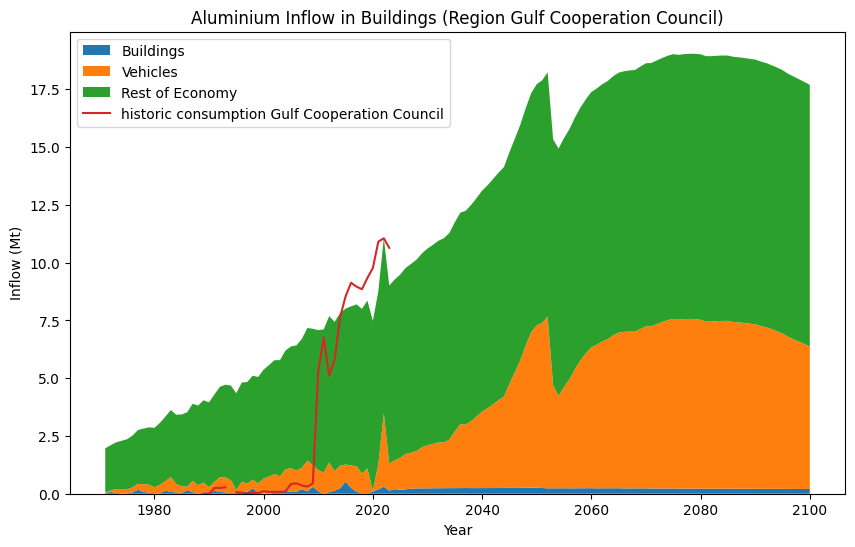

Grouping: North America, Regions: ['class_ 1', 'class_ 2', 'class_ 3']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


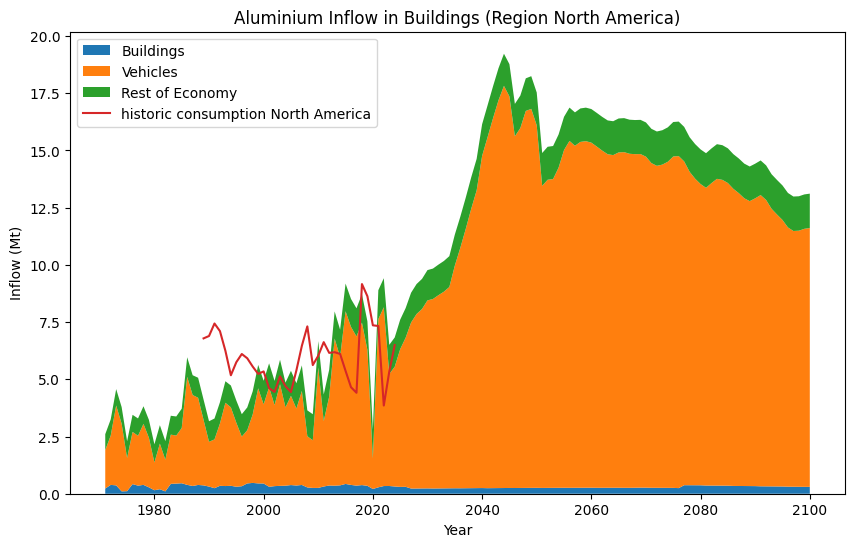

Grouping: Oceania, Regions: ['class_ 24']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


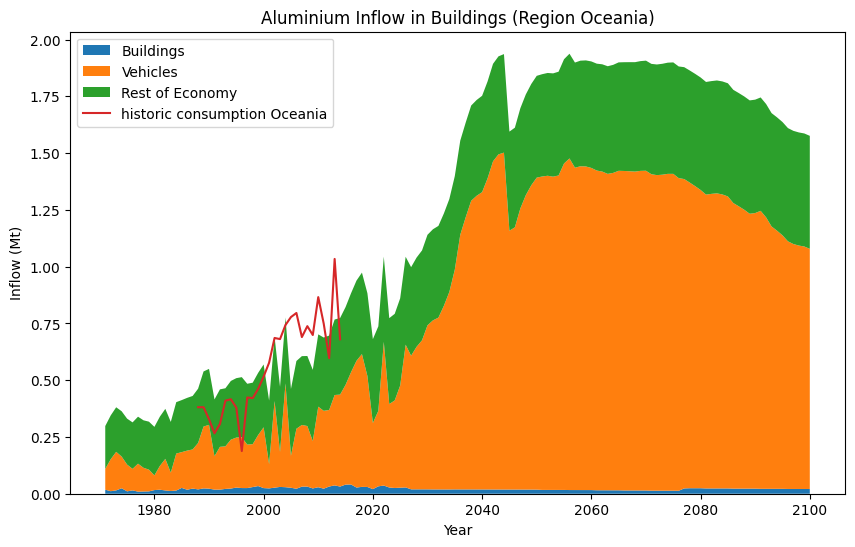

Grouping: Russia & Eastern Europe, Regions: ['class_ 12', 'class_ 14', 'class_ 15', 'class_ 16']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


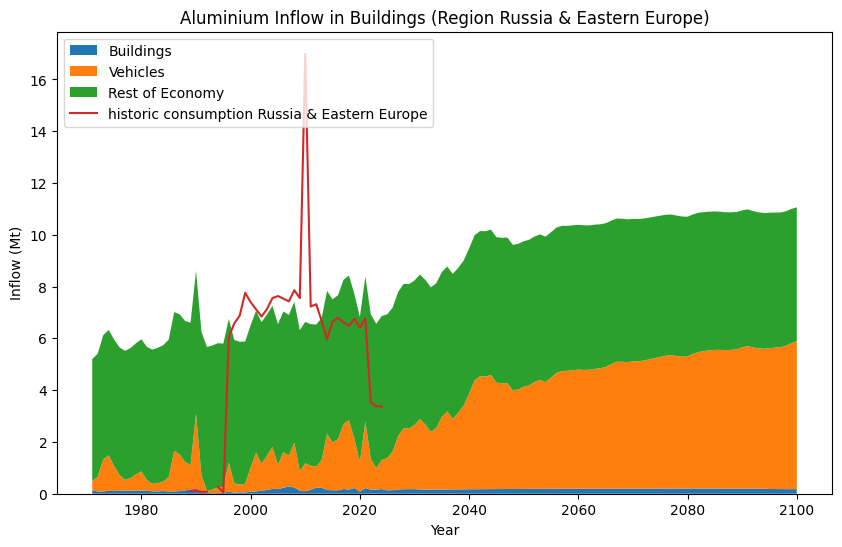

Grouping: South America, Regions: ['class_ 4', 'class_ 5', 'class_ 6']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


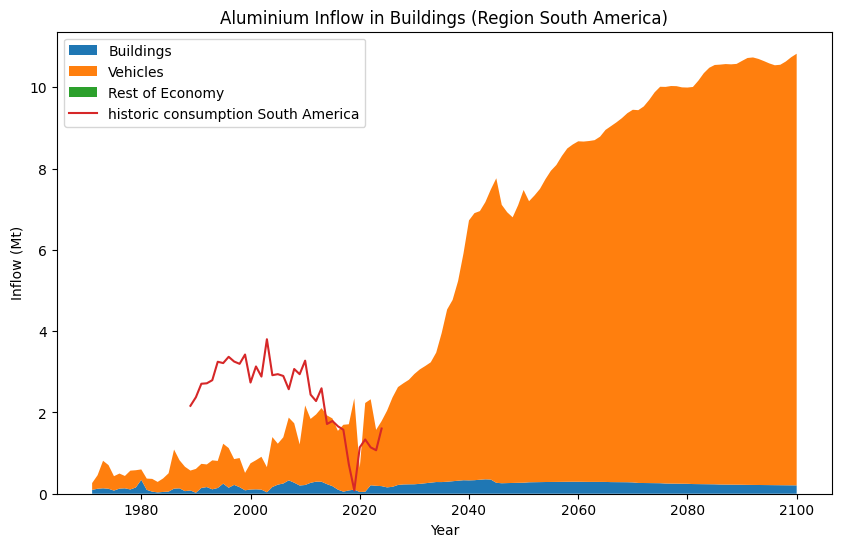

Grouping: Western & Central Europe, Regions: ['class_ 11', 'class_ 12', 'class_ 13']


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


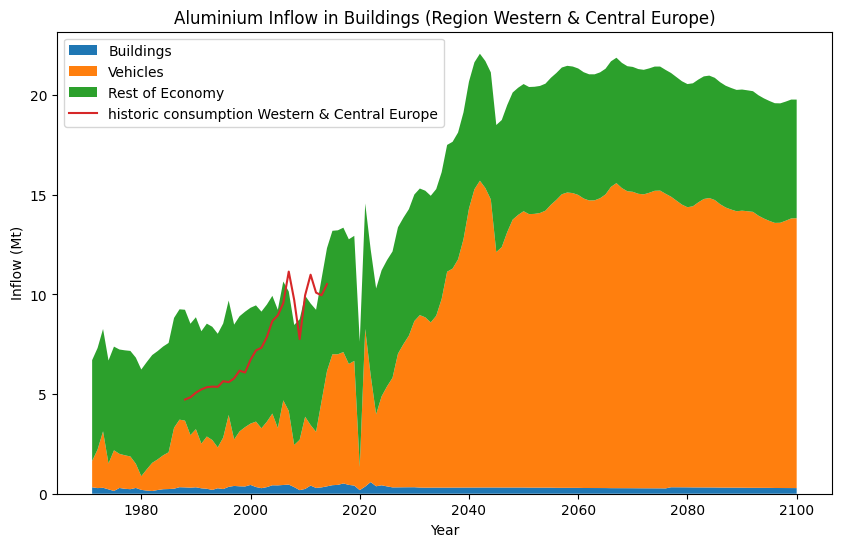

In [11]:
from imagematerials.rest_of.const import IAI_TO_IMAGE_CLASSES

for grouping, regions in IAI_TO_IMAGE_CLASSES.items():
    print(f"Grouping: {grouping}, Regions: {regions}")
    # from list [class_ 1, class_ 2, ..., class_ 26] to [1, 2, 3, ...]
    regions_str = [str(region.split("_ ")[-1]) for region in regions]

    # stack plot of material inflow in buildings and vehicles
    material_sel = "Aluminium"

    inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel, Region = regions_str).sum(["Type", "Region"]).loc[1971:].pint.to("Mt")
    inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = material_sel, Region = regions_str).sum(["Type", "Region"]).loc[1971:].pint.to("Mt")
    inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel, Region = regions_str).loc[1971:].sum(["Region"]).rename({'Time': 'time'}).pint.to("Mt")
    years = inflow_buildings.coords['time'].values

    historic_consumption_data = aluminium.historic_consumption_data.loc[:, grouping] / 1e6

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
    ax.plot(historic_consumption_data, label = f"historic consumption {grouping}")
    


    ax.set_title(f'{material_sel} Inflow in Buildings (Region {grouping})')
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflow (Mt)')
    ax.legend(loc='upper left')
    plt.show()


In [12]:
rest_sector.prep_data["gompertz_coefs"].sel(material = "Aluminium").sel(Region = "6")

<xarray.DataArray (coef: 3)> Size: 24B
array([nan, nan, nan])
Coordinates:
    Region    <U2 8B '6'
    material  <U9 36B 'Aluminium'
  * coef      (coef) <U1 12B 'a' 'b' 'c'

In [13]:
model.rest_of.get('inflow_materials_rest').sel(material="Aluminium", Region="1")

Magnitude,[55066.50153314805 55905.60562354392 56609.53833186576 57390.42790930438 58205.0788853552 58974.54694642278 59661.850530688986 60284.19738528552 60929.31180004901 61664.89267487914 62430.3858469894 63149.21181013868 63801.32001686506 64408.49688385865 65016.9064695795 65701.56851371584 66508.67223225276 67460.05435693047 68540.19269479539 69578.67017118356 70480.71838924539 71315.64633048356 72122.02048079413 72909.5013297949 73684.93172429845 74450.8022592844 75177.60315787338 75836.88125923795 76478.32267534468 77191.61398298376 77995.27112058933 78799.40625117076 79546.71053267251 80281.86372957687 81047.28142911197 81842.13343295132 82673.81605345852 83569.62520530885 84513.98838049865 85443.53377343612 86349.50656540519 87276.18400048738 88211.56593923562 89069.2362831157 89893.17038590861 90852.70354870135 91961.69756779443 93171.54810479832 94397.5246153569 95318.61707987882 95761.86751367041 96205.117947462 96648.34322372855 97091.59365752015 97534.84409131174 97934.77326697351 98334.7024426353 98734.63161829708 99134.56079395887 99534.4648120956 99905.76472425464 100277.06463641366 100648.36454857272 101019.66446073176 101390.9643728908 101729.05635198866 102067.12317356147 102405.21515265934 102743.28197423213 103081.37395333001 103402.3336578713 103723.26820488756 104044.20275190381 104365.13729892006 104686.09700346137 105019.78641567612 105353.45067036581 105687.14008258056 106020.80433727027 106354.49374948502 106638.84925508389 106923.1796031577 107207.50995123152 107491.86545683038 107776.1958049042 108044.70206972386 108313.18317701848 108581.68944183814 108850.17054913276 109118.67681395244 109366.95642863483 109615.23604331723 109863.49050047458 110111.77011515699 110360.04972983939 110593.788295045 110827.50170272557 111061.21511040613 111294.95367561174 111528.66708329231 111722.9838067503 111917.30053020829 112111.61725366625 112305.93397712425 112500.25070058224 112629.76163952083 112759.27257845944 112888.75835987298 113018.26929881156 113147.78023775018 113195.37827513786 113243.0014700506 113290.57434991324 113338.17238730093 113385.77042468861 113349.7196912972 113313.66895790579 113277.61822451437 113241.56749112296 113205.51675773154 113100.7859809636 112996.05520419565 112891.3244274277 112786.59365065976 112681.86287389182 112527.01830723156 112372.19889809634 112217.35433143607 112062.53492230085 111907.71551316563]
Units,metric_ton


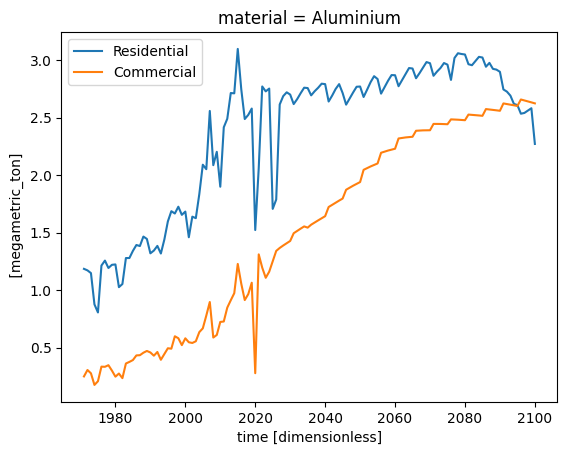

In [14]:
inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel,
                                                                          Type = ['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']).pint.to("Mt").sum(["Region", "Type"]).loc[1971:]

inflow_buildings_com = model.buildings.get('inflow_materials').to_array().sel(material = material_sel,
                                                                          Type = ['Office', 'Retail+',
       'Hotels+', 'Govt+']).pint.to("Mt").sum(["Region", "Type"]).loc[1971:]


inflow_buildings.plot(label = "Residential")
inflow_buildings_com.plot(label = "Commercial")

plt.legend()

In [15]:
total_material_dict_nmm["sand_gravel_crushed_rock"]

Region,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
time,,,,,,,,,,,,,,,,,,,,,
1971,1.635434e+07,1.588924e+08,3.203469e+07,1.454114e+07,2.803866e+07,4.774395e+07,2.083136e+07,4.319693e+07,2.586626e+07,1.090794e+07,...,4.226730e+07,1.397230e+08,1.224269e+07,2.236690e+08,4.913513e+07,3.049161e+07,5.162036e+07,1.600406e+07,4.351130e+07,1.551585e+07
1972,2.531171e+07,2.637655e+08,4.341526e+07,1.368114e+07,6.930959e+07,3.490286e+07,2.076290e+07,3.235115e+07,1.923434e+07,7.099452e+06,...,7.648543e+07,8.727750e+07,8.468853e+06,2.027112e+08,3.659449e+07,2.301010e+07,9.655968e+07,1.001301e+07,2.294449e+07,1.359454e+07
1973,1.797259e+07,2.516792e+08,4.375247e+07,1.253928e+07,8.286756e+07,3.252960e+07,1.312711e+07,3.225914e+07,1.630897e+07,4.361126e+06,...,3.122793e+07,7.528288e+07,1.154567e+07,2.146001e+08,3.545221e+07,2.932255e+07,8.134693e+07,1.373531e+07,1.720831e+07,1.400364e+07
1974,9.130733e+06,5.071189e+07,3.654597e+07,1.078907e+07,7.833521e+07,2.656319e+07,1.073925e+07,3.454775e+07,2.513602e+07,2.269806e+06,...,8.416233e+06,9.594588e+07,1.244387e+07,2.051496e+08,3.781353e+07,2.493458e+07,3.051188e+07,2.222076e+07,4.255019e+07,1.495796e+07
1975,2.175184e+07,5.019554e+07,3.722532e+07,1.098723e+07,3.015175e+07,3.712253e+07,2.037392e+07,3.993204e+07,2.524572e+07,8.166032e+06,...,2.127726e+07,1.074967e+08,1.137123e+07,1.944496e+08,3.984624e+07,2.925616e+07,9.041747e+07,9.913932e+06,3.294526e+07,1.609199e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,2.661255e+07,2.140800e+08,8.166810e+07,5.638950e+07,6.493589e+07,1.246846e+08,1.811778e+08,1.318880e+09,5.243292e+08,2.842158e+07,...,2.332538e+08,6.913220e+08,1.864466e+07,5.567918e+08,2.575237e+08,1.469768e+08,4.392451e+07,2.343805e+07,5.823458e+08,3.169321e+08
2097,2.652131e+07,2.127253e+08,8.157938e+07,5.601714e+07,6.448283e+07,1.238589e+08,1.812085e+08,1.338948e+09,5.327128e+08,2.819074e+07,...,2.329102e+08,6.885280e+08,1.833238e+07,5.482330e+08,2.567336e+08,1.465777e+08,4.351495e+07,2.342755e+07,5.636817e+08,3.197260e+08
2098,2.643251e+07,2.113659e+08,8.148508e+07,5.566476e+07,6.405224e+07,1.230492e+08,1.813107e+08,1.358424e+09,5.408337e+08,2.797235e+07,...,2.325764e+08,6.855942e+08,1.801986e+07,5.397307e+08,2.558965e+08,1.461358e+08,4.310713e+07,2.341548e+07,5.611376e+08,3.222692e+08
